In [7]:
import os
print(os.getcwd())

d:\Intership project\NetflixDataCleaningandAnalysisProject(SQL+Python)


In [12]:
import pandas as pd

df = pd.read_csv(r"D:\Intership project\NetflixDataCleaningandAnalysisProject(SQL+Python)\data\netflix_titles.csv")

df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [13]:
import pandas as pd
df = pd.read_csv(r"D:\Intership project\NetflixDataCleaningandAnalysisProject(SQL+Python)\data\netflix_titles.csv")
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [17]:
print("Shape (rows, columns):", df.shape)
print("\nColumn Names:")
print(df.columns.tolist())
print("\nData Types & Missing Values:")
df.info()

Shape (rows, columns): (8807, 12)

Column Names:
['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added', 'release_year', 'rating', 'duration', 'listed_in', 'description']

Data Types & Missing Values:
<class 'pandas.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   show_id       8807 non-null   str  
 1   type          8807 non-null   str  
 2   title         8807 non-null   str  
 3   director      6173 non-null   str  
 4   cast          7982 non-null   str  
 5   country       7976 non-null   str  
 6   date_added    8797 non-null   str  
 7   release_year  8807 non-null   int64
 8   rating        8803 non-null   str  
 9   duration      8804 non-null   str  
 10  listed_in     8807 non-null   str  
 11  description   8807 non-null   str  
dtypes: int64(1), str(11)
memory usage: 825.8 KB


In [16]:
missing = df.isnull().sum()
missing_percent = (df.isnull().sum() / len(df)) * 100

missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_percent.round(2)
})
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values('Missing Count', ascending=False)
print(missing_df)

            Missing Count  Missing %
director             2634      29.91
country               831       9.44
cast                  825       9.37
date_added             10       0.11
rating                  4       0.05
duration                3       0.03


In [18]:
df['director'] = df['director'].fillna('Unknown')
df['cast'] = df['cast'].fillna('Unknown')
df['country'] = df['country'].fillna('Unknown')

df = df.dropna(subset=['date_added', 'rating', 'duration'])

print("Missing values ab:")
print(df.isnull().sum())

print("\nNaya shape:", df.shape)

Missing values ab:
show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
description     0
dtype: int64

Naya shape: (8790, 12)


In [19]:
duplicate_count = df.duplicated().sum()
print("Total duplicate rows:", duplicate_count)

df = df.drop_duplicates()
print("Duplicates hatane ke baad shape:", df.shape)

Total duplicate rows: 0
Duplicates hatane ke baad shape: (8790, 12)


In [20]:
df['date_added'] = pd.to_datetime(df['date_added'].str.strip(), format='%B %d, %Y')

print(df['date_added'].dtype)
print(df['date_added'].head())

datetime64[us]
0   2021-09-25
1   2021-09-24
2   2021-09-24
3   2021-09-24
4   2021-09-24
Name: date_added, dtype: datetime64[us]


In [22]:
import re

# duration ko number aur type mein split karo
df['duration_number'] = df['duration'].str.extract(r'(\d+)', expand=False).astype(int)
df['duration_type'] = df['duration'].str.extract(r'([a-zA-Z ]+)', expand=False).str.strip()

print(df[['duration', 'duration_number', 'duration_type']].head(10))
print("\nUnique duration types:", df['duration_type'].unique())

    duration  duration_number duration_type
0     90 min               90           min
1  2 Seasons                2       Seasons
2   1 Season                1        Season
3   1 Season                1        Season
4  2 Seasons                2       Seasons
5   1 Season                1        Season
6     91 min               91           min
7    125 min              125           min
8  9 Seasons                9       Seasons
9    104 min              104           min

Unique duration types: <StringArray>
['min', 'Seasons', 'Season']
Length: 3, dtype: str


In [ ]:
df['duration_type'] = df['duration_type'].replace('Seasons', 'Season')

print(df['duration_type'].value_counts())

duration_type
min       6126
Season    2664
Name: count, dtype: int64


type
Movie      6126
TV Show    2664
Name: count, dtype: int64


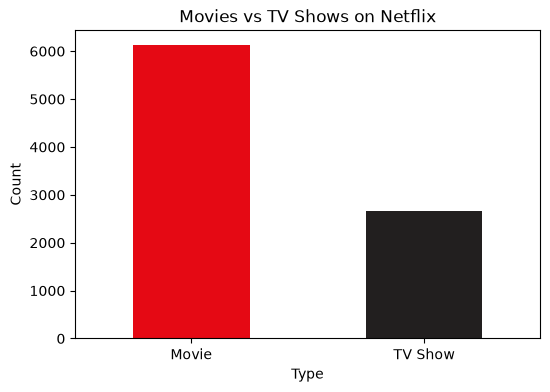

In [25]:
import matplotlib.pyplot as plt

type_counts = df['type'].value_counts()
print(type_counts)


plt.figure(figsize=(6,4))
type_counts.plot(kind='bar', color=['#E50914', '#221f1f'])
plt.title('Movies vs TV Shows on Netflix')
plt.xlabel('Type')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

year_added
2008       2
2009       2
2010       1
2011      13
2012       3
2013      11
2014      24
2015      82
2016     426
2017    1185
2018    1648
2019    2016
2020    1879
2021    1498
Name: count, dtype: int64


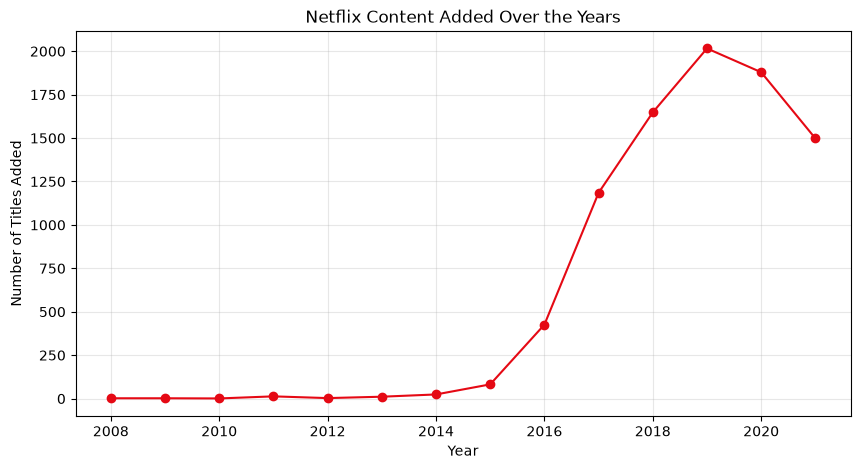

In [26]:
df['year_added'] = df['date_added'].dt.year

year_counts = df['year_added'].value_counts().sort_index()
print(year_counts)

plt.figure(figsize=(10,5))
year_counts.plot(kind='line', marker='o', color='#E50914')
plt.title('Netflix Content Added Over the Years')
plt.xlabel('Year')
plt.ylabel('Number of Titles Added')
plt.grid(True, alpha=0.3)
plt.show()

country
United States     3680
India             1046
Unknown            829
United Kingdom     803
Canada             445
France             393
Japan              316
Spain              232
South Korea        231
Germany            226
Name: count, dtype: int64


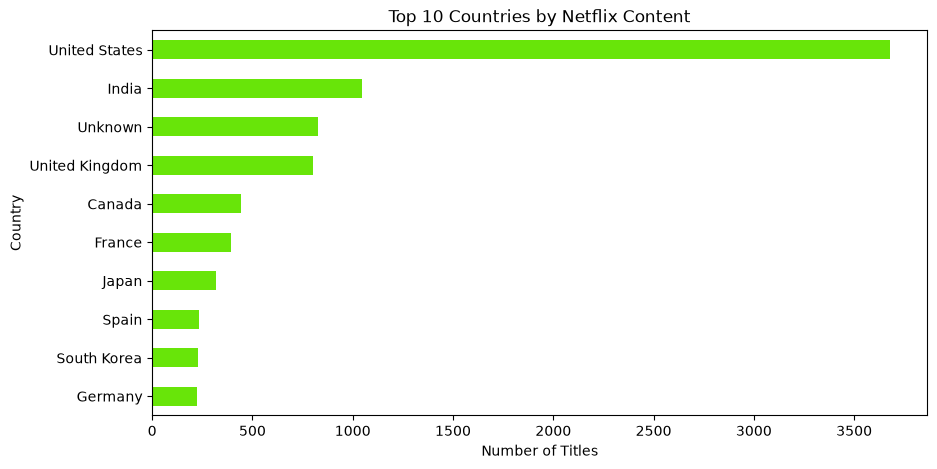

In [28]:
country_counts = df['country'].str.split(', ').explode().value_counts().head(10)
print(country_counts)

plt.figure(figsize=(10,5))
country_counts.plot(kind='barh', color="#68E509")
plt.title('Top 10 Countries by Netflix Content')
plt.xlabel('Number of Titles')
plt.ylabel('Country')
plt.gca().invert_yaxis() 

listed_in
International Movies        2752
Dramas                      2426
Comedies                    1674
International TV Shows      1349
Documentaries                869
Action & Adventure           859
TV Dramas                    762
Independent Movies           756
Children & Family Movies     641
Romantic Movies              616
Name: count, dtype: int64


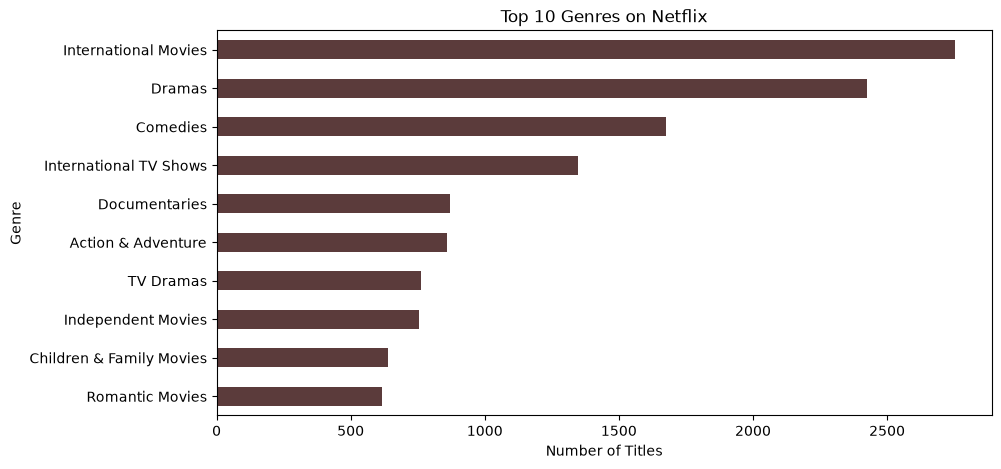

In [30]:
genre_counts = df['listed_in'].str.split(', ').explode().value_counts().head(10)
print(genre_counts)

plt.figure(figsize=(10,5))
genre_counts.plot(kind='barh', color="#5b3b3b")
plt.title('Top 10 Genres on Netflix')
plt.xlabel('Number of Titles')
plt.ylabel('Genre')
plt.gca().invert_yaxis()
plt.show()

rating
TV-MA       3205
TV-14       2157
TV-PG        861
R            799
PG-13        490
TV-Y7        333
TV-Y         306
PG           287
TV-G         220
NR            79
G             41
TV-Y7-FV       6
NC-17          3
UR             3
Name: count, dtype: int64


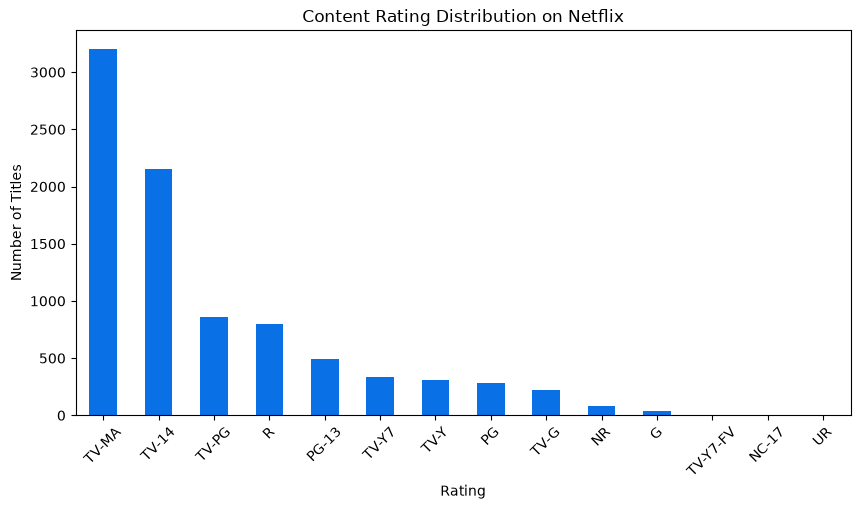

In [32]:
rating_counts = df['rating'].value_counts()
print(rating_counts)

plt.figure(figsize=(10,5))
rating_counts.plot(kind='bar', color="#0970E5")
plt.title('Content Rating Distribution on Netflix')
plt.xlabel('Rating')
plt.ylabel('Number of Titles')
plt.xticks(rotation=45)
plt.show()

In [33]:
df.to_csv(r"D:\Intership project\NetflixDataCleaningandAnalysisProject(SQL+Python)\data\netflix_titles_cleaned.csv", index=False)

print("Cleaned data saved successfully!")
print("Final shape:", df.shape)
print("\nFinal columns:", df.columns.tolist())

Cleaned data saved successfully!
Final shape: (8790, 15)

Final columns: ['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added', 'release_year', 'rating', 'duration', 'listed_in', 'description', 'duration_number', 'duration_type', 'year_added']
